# Modeling
In this notebook, we will test out various models on the dataset using SMOTENC, and k-Nearest Neighbors imputation applied.

The models will be split up into two camps: scale sensitive and scale insensitive

Their performance will be evaluated on the following metrics:
- K-Fold Cross-Validation (recall, ROC-AUC)
- score
- train & test recall
- confusion matrix
- train & test ROC-AUC

In [34]:
# Import libraries
import pandas as pd
import numpy as np

# Import dataset
df = pd.read_csv('../data/smotenc_knn_df.csv') # k-Nearest Neighbors imputed dataset with SMOTENC
df.head()

,male,age,cigsPerDay,BPMeds,prevalentHyp,totChol,BMI,heartRate,glucose,MAP,TenYearCHD
0,0.0,53.0,20.0,0.0,0.0,221.0,24.09,90.0,95.0,103.000000,0
1,0.0,64.0,6.0,0.0,1.0,239.0,20.06,55.0,73.0,103.666667,0
2,0.0,38.0,0.0,0.0,0.0,185.0,22.15,85.0,83.0,81.333333,0
3,0.0,49.0,0.0,0.0,0.0,270.0,26.56,70.0,77.0,87.166667,0
4,1.0,56.0,20.0,0.0,0.0,186.0,24.62,70.0,83.0,83.333333,0


In [35]:
# Import train, test, split
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns='TenYearCHD')
y = df['TenYearCHD']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# Import libraries
from sklearn.linear_model import LogisticRegression # Scale sensitive
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier


# Dictionary of scale insensitive models
scale_ins_models = {
    'XGBoost': xgb.XGBClassifier(),
    'Gradient Boosting' : GradientBoostingClassifier(),
    'Random Forest' : RandomForestClassifier(random_state=42)
}

# Dictionary of scale sensitive models
scale_sens_models = {
    'k-Nearest Neighbors': KNeighborsClassifier(n_neighbors=8),
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'SVC' : SVC()
}

# Scale Insensitive Models



--Evaluating XGBoost--

Cross-Validation Results:
Recall: 0.86, ROC-AUC: 0.94 +- 0.004

Score: 0.89
Training Recall: 0.99
Test Recall: 0.88

Classification Report:
              precision  recall  f1-score  support
0                  0.88    0.90      0.89   577.00
1                  0.89    0.88      0.89   572.00
accuracy           0.89    0.89      0.89     0.89
macro avg          0.89    0.89      0.89  1149.00
weighted avg       0.89    0.89      0.89  1149.00


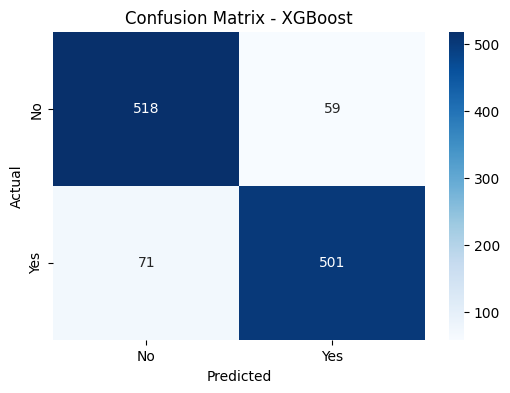

Test ROC-AUC: 0.95
Train ROC-AUC: 1.00



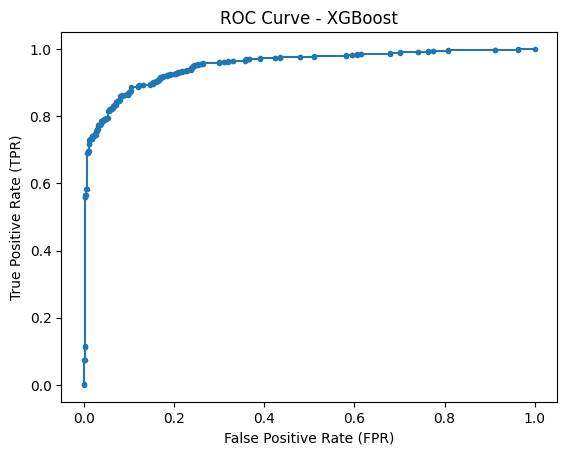

False Positive Rate (FPR): 0.000


--Evaluating Gradient Boosting--

Cross-Validation Results:
Recall: 0.83, ROC-AUC: 0.89 +- 0.013

Score: 0.83
Training Recall: 0.86
Test Recall: 0.84

Classification Report:
              precision  recall  f1-score  support
0                  0.84    0.81      0.82   577.00
1                  0.81    0.84      0.83   572.00
accuracy           0.83    0.83      0.83     0.83
macro avg          0.83    0.83      0.83  1149.00
weighted avg       0.83    0.83      0.83  1149.00


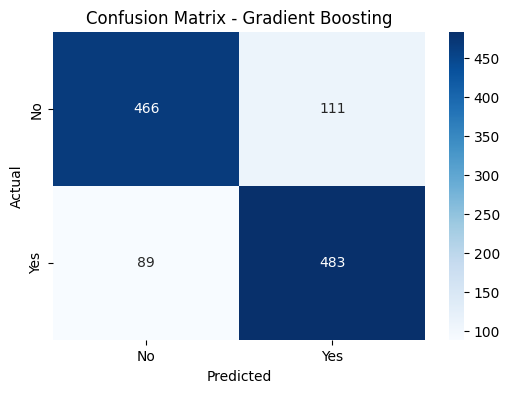

Test ROC-AUC: 0.90
Train ROC-AUC: 0.93



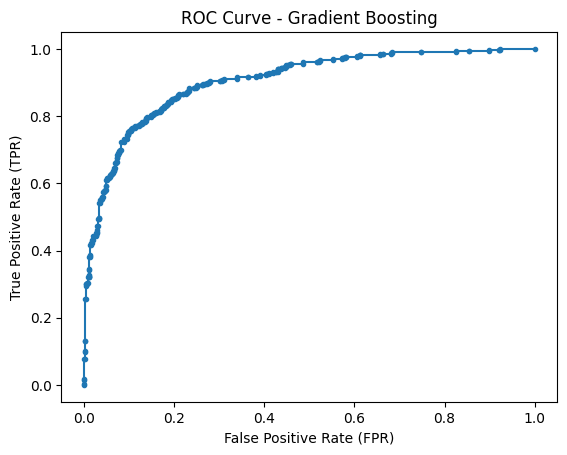

False Positive Rate (FPR): 0.000


--Evaluating Random Forest--

Cross-Validation Results:
Recall: 0.88, ROC-AUC: 0.94 +- 0.004

Score: 0.88
Training Recall: 1.00
Test Recall: 0.91

Classification Report:
              precision  recall  f1-score  support
0                  0.90    0.86      0.88   577.00
1                  0.86    0.91      0.89   572.00
accuracy           0.88    0.88      0.88     0.88
macro avg          0.88    0.88      0.88  1149.00
weighted avg       0.88    0.88      0.88  1149.00


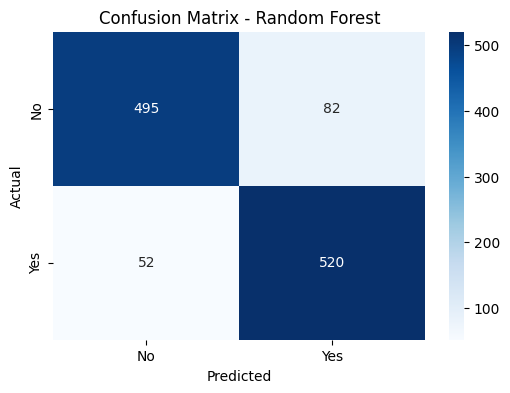

Test ROC-AUC: 0.96
Train ROC-AUC: 1.00



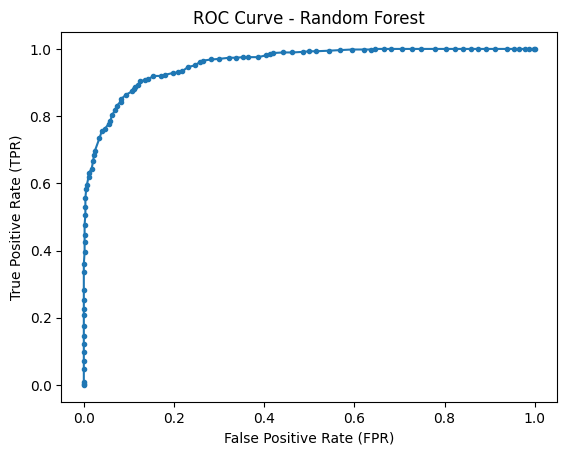

False Positive Rate (FPR): 0.000


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score, cross_validate

# Evaluate each model
for name, model in scale_ins_models.items():
    print(f'\n\n--Evaluating {name}--\n')
    
    # Perform cross-validation
    cv_results = cross_validate(
        model, X_train, y_train, cv=5, scoring=['recall', 'roc_auc'], return_train_score=True
    )
    print(f"Cross-Validation Results:\nRecall: {cv_results['test_recall'].mean():.2f}, "
          f"ROC-AUC: {cv_results['test_roc_auc'].mean():.2f} +- {cv_results['test_roc_auc'].std():.3f}\n")

    # Fit the model
    model.fit(X_train, y_train)
    print(f'Score: {model.score(X_test, y_test):.2f}')
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Recall
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    print(f'Training Recall: {train_recall:.2f}')
    print(f'Test Recall: {test_recall:.2f}\n')

    # Classification Report
    report = classification_report(y_test, y_test_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(2)
    print('Classification Report:')
    print(report_df)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # ROC-AUC
    test_roc_auc = roc_auc_score(y_test, y_test_proba)
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    print(f'Test ROC-AUC: {test_roc_auc:.2f}')
    print(f'Train ROC-AUC: {train_roc_auc:.2f}\n')

    # False Positive Rate and True Positive Rate

    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
    plt.plot(fpr, tpr, marker='.')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.show()
    
    # Report specific FPR
    fpr_value = fpr[1] 
    print(f'False Positive Rate (FPR): {fpr_value:.3f}')


# Scale Sensitive
We will now apply our scale senstive models (KNN, Logistic Regression, SVC)

The StandardScaler is applied to scale the continuous features, since they all use different units to measure different things.



--Evaluating k-Nearest Neighbors--

Cross-Validation Results:
Recall: 0.87, ROC-AUC: 0.86 +- 0.010

Score: 0.77
Training Recall: 0.93
Test Recall: 0.87

Classification Report:
              precision  recall  f1-score  support
0                  0.85    0.67      0.75   525.00
1                  0.71    0.87      0.78   483.00
accuracy           0.77    0.77      0.77     0.77
macro avg          0.78    0.77      0.76  1008.00
weighted avg       0.78    0.77      0.76  1008.00


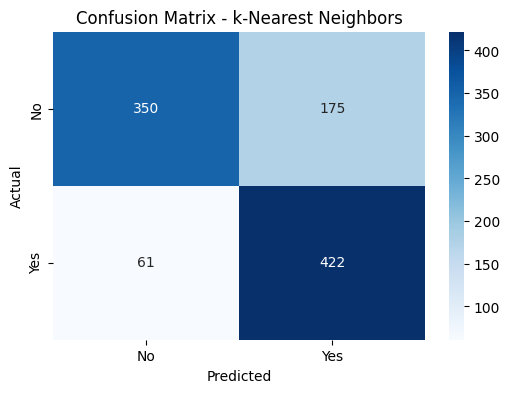

Test ROC-AUC: 0.85
Train ROC-AUC: 0.94



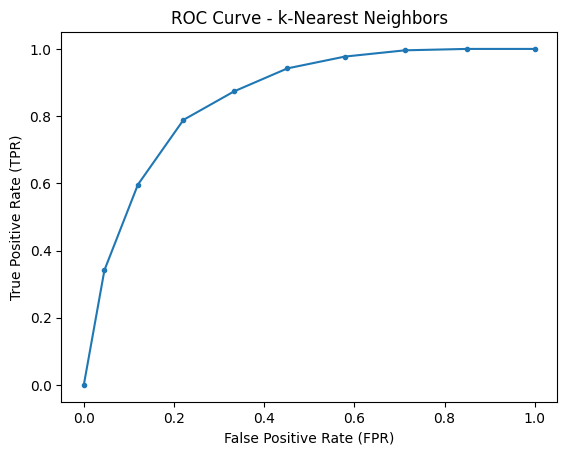

False Positive Rate (FPR): 0.046


--Evaluating Logistic Regression--

Cross-Validation Results:
Recall: 0.73, ROC-AUC: 0.76 +- 0.007

Score: 0.66
Training Recall: 0.73
Test Recall: 0.70

Classification Report:
              precision  recall  f1-score  support
0                  0.70    0.63      0.66   525.00
1                  0.63    0.70      0.67   483.00
accuracy           0.66    0.66      0.66     0.66
macro avg          0.67    0.67      0.66  1008.00
weighted avg       0.67    0.66      0.66  1008.00


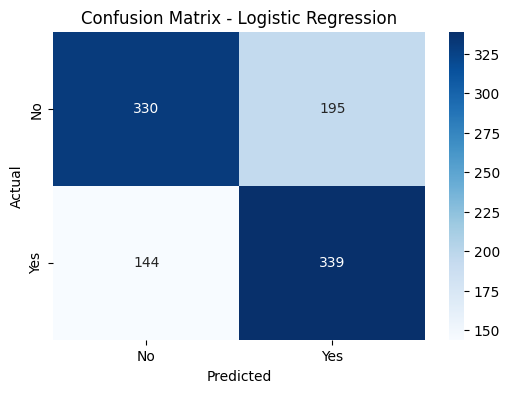

Test ROC-AUC: 0.73
Train ROC-AUC: 0.77



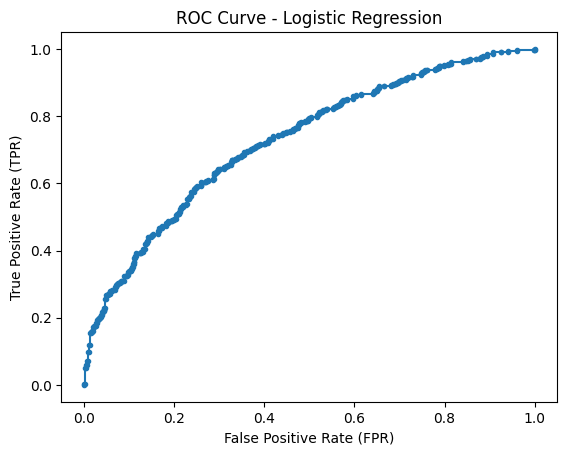

False Positive Rate (FPR): 0.000


--Evaluating SVC--

Cross-Validation Results:
Recall: 0.78, ROC-AUC: 0.82 +- 0.007

Score: 0.72
Training Recall: 0.80
Test Recall: 0.74

Classification Report:
              precision  recall  f1-score  support
0                  0.75    0.70      0.72   525.00
1                  0.70    0.74      0.72   483.00
accuracy           0.72    0.72      0.72     0.72
macro avg          0.72    0.72      0.72  1008.00
weighted avg       0.72    0.72      0.72  1008.00


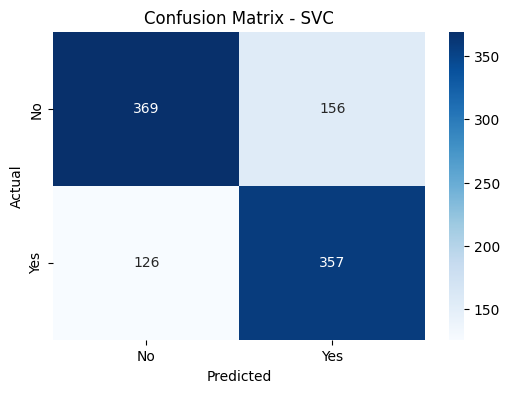

Test ROC-AUC: 0.80
Train ROC-AUC: 0.85



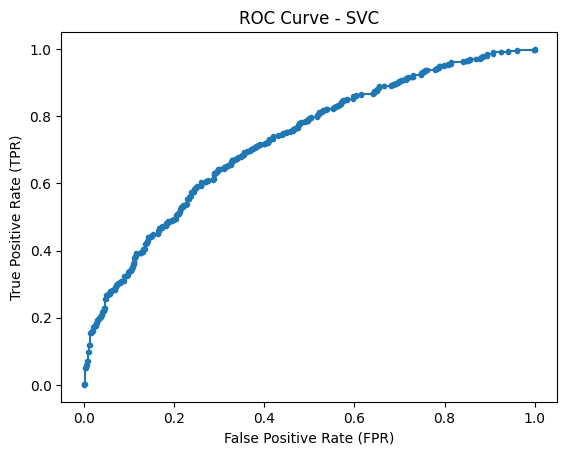

False Positive Rate (FPR): 0.000


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# List of continuous features
cont_features = ['age', 'cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose', 'MAP']

# Evaluate each model
for name, model in scale_sens_models.items():
    print(f'\n\n--Evaluating {name}--\n')

    # Create the pipeline with a ColumnTransformer to scale continuous features
    preprocessor = ColumnTransformer(
        transformers=[
            ('scaler', StandardScaler(), cont_features)  # Apply StandardScaler to continuous features
        ], 
        remainder='passthrough'  # Leave the other columns (non-continuous) unchanged
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),  # Apply preprocessing (scaling)
        ('model', model)  # Model step
    ])
    
    # Perform cross-validation
    cv_results = cross_validate(
        pipeline, X_train, y_train, cv=5, scoring=['recall', 'roc_auc'], return_train_score=True
    )
    print(f"Cross-Validation Results:\nRecall: {cv_results['test_recall'].mean():.2f}, "
          f"ROC-AUC: {cv_results['test_roc_auc'].mean():.2f} +- {cv_results['test_roc_auc'].std():.3f}\n")

    # Fit the model
    pipeline.fit(X_train, y_train)
    print(f'Score: {pipeline.score(X_test, y_test):.2f}')
    
    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Get probabilities for test/train ROC-AUC calculation
    if name != 'SVC':
        y_train_proba = pipeline.predict_proba(X_train)[:, 1]
        y_test_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        train_decision_values = pipeline.decision_function(X_train)
        test_decision_values = pipeline.decision_function(X_test)

    # Recall
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    print(f'Training Recall: {train_recall:.2f}')
    print(f'Test Recall: {test_recall:.2f}\n')

    # Classification Report
    report = classification_report(y_test, y_test_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(2)
    print('Classification Report:')
    print(report_df)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # ROC-AUC
    if name != 'SVC':
        test_roc_auc = roc_auc_score(y_test, y_test_proba)
        train_roc_auc = roc_auc_score(y_train, y_train_proba)
    else:
        train_roc_auc = roc_auc_score(y_train, train_decision_values)
        test_roc_auc = roc_auc_score(y_test, test_decision_values)
        
    print(f'Test ROC-AUC: {test_roc_auc:.2f}')
    print(f'Train ROC-AUC: {train_roc_auc:.2f}\n')

    # False Positive Rate and True Positive Rate
    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
    plt.plot(fpr, tpr, marker='.')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.show()
    
    # Report specific FPR
    fpr_value = fpr[1]  # Get FPR for the first threshold
    print(f'False Positive Rate (FPR): {fpr_value:.3f}')


It appears that Logistic Regression yields the worst results out of the three, though not by very much.

SVC is quite comparable to Logistic Regression in terms of performance, but only by a trivial margin.

KNN is the clear winner, with little sign of overfitting given its train/test ROC-AUC, and it keeps false negatives to a minimum, though it does not do a specacular job with false positives. Becuase this model seeks to predict heart disease risk, false negatives are a very costly and dangerous problem.